In [162]:
import yfinance as yf
import pandas as pd
import numpy as np
import nltk
import re
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Datasets

Yahoo Finance API

In [9]:
# Yahoo Finance S&P 500 dataset
sp500 = yf.download("^GSPC", start="1900-01-01", auto_adjust=False).reset_index()

# flatten columns in case yfinance returns MultiIndex columns
if isinstance(sp500.columns, pd.MultiIndex):
    sp500.columns = [col[0] for col in sp500.columns]

sp500 = sp500.rename(columns={"Date": "date"})
sp500["date"] = pd.to_datetime(sp500["date"])

[*********************100%***********************]  1 of 1 completed


Kaggle Headline data

In [13]:
# Kaggle sentiment dataset
df_raw = pd.read_csv("sp500_headlines_2008_2024.csv")

df_raw = df_raw.rename(columns={
    "Title": "headline",
    "Date": "date",
    "CP": "close"
})

df_raw["date"] = pd.to_datetime(df_raw["date"], errors="coerce")
df_raw["headline"] = df_raw["headline"].astype(str).str.strip()
df_raw["close"] = pd.to_numeric(df_raw["close"], errors="coerce")

df_raw = df_raw.dropna(subset=["date", "headline", "close"]).reset_index(drop=True)

# Sync datasets
- Same date beginning and end
- Match headline dates to trading days.

Cleans and aligns data

In [100]:
# ----------------------------
# Price data from Yahoo Finance
# ----------------------------
price_df = sp500.copy()

if isinstance(price_df.columns, pd.MultiIndex):
    price_df.columns = [col[0] for col in price_df.columns]

if "Date" in price_df.columns:
    price_df = price_df.rename(columns={"Date": "date"})

price_df["date"] = pd.to_datetime(price_df["date"], errors="coerce").dt.normalize()
price_df = price_df.sort_values("date").reset_index(drop=True)

# ----------------------------
# Headline data
# ----------------------------
news_df = pd.read_csv("sp500_headlines_2008_2024.csv")

news_df = news_df.rename(columns={
    "Date": "date",
    "Title": "headline"
})

news_df["date"] = pd.to_datetime(news_df["date"], errors="coerce").dt.normalize()
news_df["headline"] = news_df["headline"].astype(str).str.strip()

news_df = (
    news_df.dropna(subset=["date", "headline"])
    .query("headline != ''")
    .drop_duplicates(subset=["date", "headline"])
    .sort_values("date")
    .reset_index(drop=True)
)

print("Price date range:", price_df["date"].min(), "to", price_df["date"].max())
print("Headline date range:", news_df["date"].min(), "to", news_df["date"].max())
print(news_df.head())

Price date range: 1927-12-30 00:00:00 to 2026-03-13 00:00:00
Headline date range: 2008-01-02 00:00:00 to 2024-03-04 00:00:00
                                            headline       date       CP
0   JPMorgan Predicts 2008 Will Be "Nothing But Net" 2008-01-02  1447.16
1  Dow Tallies Biggest First-session-of-year Poin... 2008-01-02  1447.16
2                   2008 predictions for the S&P 500 2008-01-02  1447.16
3  U.S. Stocks Higher After Economic Data, Monsan... 2008-01-03  1447.16
4  U.S. Stocks Climb As Hopes Increase For More F... 2008-01-07  1416.18


In [143]:
shared_start = news_df["date"].min()
shared_end = news_df["date"].max()

price_df = price_df[
    (price_df["date"] >= shared_start) &
    (price_df["date"] <= shared_end)
].copy()

print("price_df synced min/max:", price_df["date"].min(), price_df["date"].max())

price_df synced min/max: 2008-01-02 00:00:00 2024-03-04 00:00:00


In [ ]:
trading_dates = pd.Index(price_df["date"].sort_values().unique())

def map_to_next_trading_day(d):
    idx = trading_dates.searchsorted(d)
    if idx >= len(trading_dates):
        return pd.NaT
    return trading_dates[idx]

news_df["market_date"] = news_df["date"].apply(map_to_next_trading_day)
news_df = news_df.dropna(subset=["market_date"]).copy()

print(news_df[["date", "market_date", "headline"]].head(10))

# BASELINE MODEL

# Feature Engineering

### Baseline
- 1 day return
- 5 day return
- 10 day return
- 10 day moving average deviation
- 5 day volatility
- 1 day volume change

In [145]:
import numpy as np

price_col = "Adj Close" if "Adj Close" in price_df.columns else "Close"

# returns
price_df["ret_1"] = price_df[price_col].pct_change(1)
price_df["ret_5"] = price_df[price_col].pct_change(5)
price_df["ret_10"] = price_df[price_col].pct_change(10)

# moving average deviation
price_df["ma_10"] = price_df[price_col].rolling(10).mean()
price_df["ma_10_dev"] = price_df[price_col] / price_df["ma_10"] - 1

# volatility
price_df["vol_5"] = price_df["ret_1"].rolling(5).std()

# target
price_df["next_ret"] = price_df[price_col].pct_change().shift(-1)
price_df["target"] = (price_df["next_ret"] > 0).astype(int)

feature_cols = [
    "ret_1",
    "ret_5",
    "ret_10",
    "ma_10_dev",
    "vol_5"
]

price_df = price_df.replace([np.inf, -np.inf], np.nan)

model_df = price_df[["date"] + feature_cols + ["target", "next_ret"]].dropna().reset_index(drop=True)

print("model_df rebuilt min/max:", model_df["date"].min(), model_df["date"].max())
print(model_df.shape)

model_df rebuilt min/max: 2008-01-16 00:00:00 2024-03-01 00:00:00
(4059, 8)


# Training dataset
- 70/30 Chronological split

In [79]:
# 70/30 chronological split
split_idx = int(len(model_df) * 0.7)

train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols]
y_train = train_df["target"]

X_test = test_df[feature_cols]
y_test = test_df["target"]

print("Train size:", len(train_df))
print("Test size:", len(test_df))
print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())
print("Features:", feature_cols)

Train size: 13416
Test size: 5751
Train date range: 1950-01-04 00:00:00 to 2003-05-01 00:00:00
Test date range: 2003-05-02 00:00:00 to 2026-03-12 00:00:00
Features: ['ret_1', 'ret_5', 'ret_10', 'ma_10_dev', 'vol_5', 'volchg_1']


# MODELS
- Logistics regression
- Random Forest
- Gradient Boosting
- SVM

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ]),
    
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            random_state=42
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("clf", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            probability=True,
            kernel="rbf",
            C=1.0,
            random_state=42
        ))
    ])
}

# Evaluation

In [91]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_df.round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,Gradient Boosting,0.4997,0.5381,0.6019,0.5682,0.4871
1,SVM,0.5070,0.5373,0.7091,0.6114,0.4834
2,Random Forest,0.5023,0.5377,0.6420,0.5852,0.4832
3,Logistic Regression,0.5110,0.5384,0.7415,0.6239,0.4753


In [93]:
best_model_name = results_df.iloc[0]["model"]
print("Best baseline model:", best_model_name)

Best baseline model: Gradient Boosting


# SENTIMENT MODEL

# Score each headline 

In [183]:
# ------------------------------------------------------------------
# Aggregate scored headlines to daily sentiment before merging
# ------------------------------------------------------------------

# make sure dates are datetime
headlines_df["date"] = pd.to_datetime(headlines_df["date"], errors="coerce").dt.normalize()
price_df["date"] = pd.to_datetime(price_df["date"], errors="coerce").dt.normalize()

# map each headline date to the next trading day
trading_dates = pd.Index(price_df["date"].sort_values().unique())

def map_to_next_trading_day(d):
    idx = trading_dates.searchsorted(d)
    if idx >= len(trading_dates):
        return pd.NaT
    return trading_dates[idx]

headlines_df["market_date"] = headlines_df["date"].apply(map_to_next_trading_day)
headlines_df = headlines_df.dropna(subset=["market_date"]).copy()

# if using VADER scores:
# expected columns:
# sent_neg, sent_neu, sent_pos, sent_compound

sent_daily = (
    headlines_df.groupby("market_date")
    .agg(
        sent_same_day=("sent_compound", "mean"),
        neg_same_day=("sent_neg", "mean"),
        neu_same_day=("sent_neu", "mean"),
        pos_same_day=("sent_pos", "mean"),
        headline_count=("headline", "size")
    )
    .reset_index()
    .rename(columns={"market_date": "date"})
    .sort_values("date")
)

print(sent_daily.head())
print(sent_daily.shape)
print("sent_daily range:", sent_daily["date"].min(), "to", sent_daily["date"].max())

        date  sent_same_day  neg_same_day  neu_same_day  pos_same_day  \
0 2008-01-22         0.0000      0.000000      1.000000         0.000   
1 2008-01-29         0.0000      0.000000      1.000000         0.000   
2 2008-01-30         0.5994      0.000000      0.562000         0.438   
3 2008-02-01         0.0772      0.000000      0.755000         0.245   
4 2008-02-05        -0.1405      0.119667      0.880333         0.000   

   headline_count  
0               4  
1               1  
2               1  
3               1  
4               3  
(3501, 6)
sent_daily range: 2008-01-22 00:00:00 to 2024-03-01 00:00:00


# Merge headline + price data

In [186]:
# ------------------------------------------------------------------
# Merge headline + price data
# ------------------------------------------------------------------
model_df_sent = model_df.merge(sent_daily, on="date", how="left")

fill_zero_cols = [
    "sent_same_day",
    "neg_same_day",
    "neu_same_day",
    "pos_same_day",
    "headline_count"
]

for col in fill_zero_cols:
    model_df_sent[col] = model_df_sent[col].fillna(0)

print(model_df_sent.head())
print(model_df_sent.shape)

        date     ret_1     ret_5    ret_10  ma_10_dev     vol_5  target  \
0 2008-01-16 -0.005612 -0.025498 -0.051107  -0.023748  0.014923       0   
1 2008-01-17 -0.029093 -0.061310 -0.078713  -0.044411  0.016004       0   
2 2008-01-18 -0.006045 -0.054125 -0.061234  -0.044267  0.016226       0   
3 2008-01-22 -0.011085 -0.074669 -0.074623  -0.047602  0.010956       1   
4 2008-01-23  0.021442 -0.030667 -0.037110  -0.023520  0.018113       1   

   next_ret  sent_same_day  neg_same_day  neu_same_day  pos_same_day  \
0 -0.029093            0.0           0.0           0.0           0.0   
1 -0.006045            0.0           0.0           0.0           0.0   
2 -0.011085            0.0           0.0           0.0           0.0   
3  0.021442            0.0           0.0           1.0           0.0   
4  0.010063            0.0           0.0           0.0           0.0   

   headline_count  
0             0.0  
1             0.0  
2             0.0  
3             4.0  
4             0.

# Feature Engineering

- Sentiment same day
- Negative same day
- Positive same day
- Neutral same day
- headline count
- 3 day average sentiment
- 3 day average negative sentiment
- 3 day average positive sentiment
- 3 day headline count sum

In [195]:
model_df_sent = model_df_sent.sort_values("date").reset_index(drop=True)

# rolling sentiment features
model_df_sent["sent_3d_avg"] = model_df_sent["sent_same_day"].rolling(3, min_periods=1).mean()
model_df_sent["neg_3d_avg"] = model_df_sent["neg_same_day"].rolling(3, min_periods=1).mean()
model_df_sent["pos_3d_avg"] = model_df_sent["pos_same_day"].rolling(3, min_periods=1).mean()
model_df_sent["headline_count_3d"] = model_df_sent["headline_count"].rolling(3, min_periods=1).sum()

feature_cols_sent = feature_cols + [
    "sent_same_day",
    "neg_same_day",
    "neu_same_day",
    "pos_same_day",
    "headline_count",
    "sent_3d_avg",
    "neg_3d_avg",
    "pos_3d_avg",
    "headline_count_3d"
]

model_df_sent = model_df_sent[["date"] + feature_cols_sent + ["target", "next_ret"]].dropna().reset_index(drop=True)

print(feature_cols_sent)
print(model_df_sent.head())
print(model_df_sent.shape)

['ret_1', 'ret_5', 'ret_10', 'ma_10_dev', 'vol_5', 'sent_same_day', 'neg_same_day', 'neu_same_day', 'pos_same_day', 'headline_count', 'sent_3d_avg', 'neg_3d_avg', 'pos_3d_avg', 'headline_count_3d']
        date     ret_1     ret_5    ret_10  ma_10_dev     vol_5  \
0 2008-01-16 -0.005612 -0.025498 -0.051107  -0.023748  0.014923   
1 2008-01-17 -0.029093 -0.061310 -0.078713  -0.044411  0.016004   
2 2008-01-18 -0.006045 -0.054125 -0.061234  -0.044267  0.016226   
3 2008-01-22 -0.011085 -0.074669 -0.074623  -0.047602  0.010956   
4 2008-01-23  0.021442 -0.030667 -0.037110  -0.023520  0.018113   

   sent_same_day  neg_same_day  neu_same_day  pos_same_day  headline_count  \
0            0.0           0.0           0.0           0.0             0.0   
1            0.0           0.0           0.0           0.0             0.0   
2            0.0           0.0           0.0           0.0             0.0   
3            0.0           0.0           1.0           0.0             4.0   
4        

# Training

In [201]:
split_idx_sent = int(len(model_df_sent) * 0.7)

train_df_sent = model_df_sent.iloc[:split_idx_sent].copy()
test_df_sent = model_df_sent.iloc[split_idx_sent:].copy()

X_train_sent = train_df_sent[feature_cols_sent]
y_train_sent = train_df_sent["target"]

X_test_sent = test_df_sent[feature_cols_sent]
y_test_sent = test_df_sent["target"]

print("Train size:", len(train_df_sent))
print("Test size:", len(test_df_sent))
print("Train date range:", train_df_sent["date"].min(), "to", train_df_sent["date"].max())
print("Test date range:", test_df_sent["date"].min(), "to", test_df_sent["date"].max())

Train size: 2841
Test size: 1218
Train date range: 2008-01-16 00:00:00 to 2019-04-30 00:00:00
Test date range: 2019-05-01 00:00:00 to 2024-03-01 00:00:00


# Models

In [203]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=3000))
    ]),
    
    "Random Forest": Pipeline([
        ("clf", RandomForestClassifier(
            n_estimators=200,
            max_depth=5,
            random_state=42
        ))
    ]),
    
    "Gradient Boosting": Pipeline([
        ("clf", GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=3,
            random_state=42
        ))
    ]),
    
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", SVC(
            probability=True,
            kernel="rbf",
            C=1.0,
            random_state=42
        ))
    ])
}

# Evaulate

In [206]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import pandas as pd

results_sent = []

for name, model in models.items():
    model.fit(X_train_sent, y_train_sent)

    y_pred_sent = model.predict(X_test_sent)
    y_prob_sent = model.predict_proba(X_test_sent)[:, 1]

    results_sent.append({
        "model": name,
        "accuracy": accuracy_score(y_test_sent, y_pred_sent),
        "precision": precision_score(y_test_sent, y_pred_sent),
        "recall": recall_score(y_test_sent, y_pred_sent),
        "f1": f1_score(y_test_sent, y_pred_sent),
        "roc_auc": roc_auc_score(y_test_sent, y_prob_sent)
    })

results_sent_df = pd.DataFrame(results_sent).sort_values("roc_auc", ascending=False).reset_index(drop=True)
display(results_sent_df.round(4))

,model,accuracy,precision,recall,f1,roc_auc
0,Random Forest,0.5476,0.5462,0.9389,0.6906,0.5189
1,SVM,0.5386,0.5393,0.9740,0.6942,0.5082
2,Logistic Regression,0.5361,0.5381,0.9695,0.6921,0.5054
3,Gradient Boosting,0.5328,0.5431,0.8275,0.6558,0.5001


In [208]:
comparison_df = results_df.merge(
    results_sent_df,
    on="model",
    suffixes=("_price_only", "_price_sent")
)

pretty_comparison = pd.DataFrame({
    "Model": comparison_df["model"],

    "Accuracy (Price Only)": comparison_df["accuracy_price_only"],
    "Accuracy (Price+Sent)": comparison_df["accuracy_price_sent"],
    "Accuracy Diff": comparison_df["accuracy_price_sent"] - comparison_df["accuracy_price_only"],

    "Precision (Price Only)": comparison_df["precision_price_only"],
    "Precision (Price+Sent)": comparison_df["precision_price_sent"],
    "Precision Diff": comparison_df["precision_price_sent"] - comparison_df["precision_price_only"],

    "Recall (Price Only)": comparison_df["recall_price_only"],
    "Recall (Price+Sent)": comparison_df["recall_price_sent"],
    "Recall Diff": comparison_df["recall_price_sent"] - comparison_df["recall_price_only"],

    "F1 (Price Only)": comparison_df["f1_price_only"],
    "F1 (Price+Sent)": comparison_df["f1_price_sent"],
    "F1 Diff": comparison_df["f1_price_sent"] - comparison_df["f1_price_only"],

    "ROC AUC (Price Only)": comparison_df["roc_auc_price_only"],
    "ROC AUC (Price+Sent)": comparison_df["roc_auc_price_sent"],
    "ROC AUC Diff": comparison_df["roc_auc_price_sent"] - comparison_df["roc_auc_price_only"],
})

display(pretty_comparison.round(4).sort_values("ROC AUC Diff", ascending=False))

,Model,Accuracy (Price Only),Accuracy (Price+Sent),Accuracy Diff,Precision (Price Only),Precision (Price+Sent),Precision Diff,Recall (Price Only),Recall (Price+Sent),Recall Diff,F1 (Price Only),F1 (Price+Sent),F1 Diff,ROC AUC (Price Only),ROC AUC (Price+Sent),ROC AUC Diff
2,Random Forest,0.5023,0.5476,0.0453,0.5377,0.5462,0.0085,0.6420,0.9389,0.2970,0.5852,0.6906,0.1054,0.4832,0.5189,0.0357
3,Logistic Regression,0.5110,0.5361,0.0251,0.5384,0.5381,-0.0003,0.7415,0.9695,0.2280,0.6239,0.6921,0.0682,0.4753,0.5054,0.0301
1,SVM,0.5070,0.5386,0.0315,0.5373,0.5393,0.0020,0.7091,0.9740,0.2650,0.6114,0.6942,0.0829,0.4834,0.5082,0.0248
0,Gradient Boosting,0.4997,0.5328,0.0331,0.5381,0.5431,0.0050,0.6019,0.8275,0.2256,0.5682,0.6558,0.0876,0.4871,0.5001,0.0131


In [210]:
from sklearn.metrics import confusion_matrix, roc_curve, auc, precision_recall_curve
import pandas as pd
import numpy as np

baseline_preds = {}
sentiment_preds = {}

for name, model in models.items():
    # baseline
    model.fit(X_train, y_train)
    y_pred_base = model.predict(X_test)
    y_prob_base = model.predict_proba(X_test)[:, 1]
    
    baseline_preds[name] = {
        "y_true": y_test,
        "y_pred": y_pred_base,
        "y_prob": y_prob_base
    }
    
    # sentiment
    model.fit(X_train_sent, y_train_sent)
    y_pred_sent = model.predict(X_test_sent)
    y_prob_sent = model.predict_proba(X_test_sent)[:, 1]
    
    sentiment_preds[name] = {
        "y_true": y_test_sent,
        "y_pred": y_pred_sent,
        "y_prob": y_prob_sent
    }

print("Stored predictions for:", list(models.keys()))

Stored predictions for: ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']


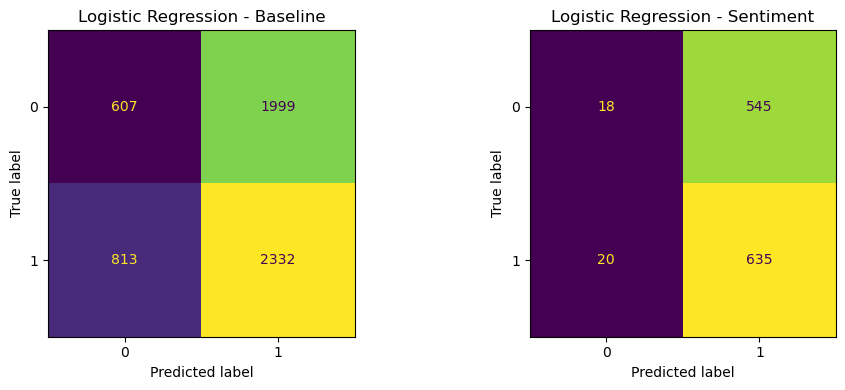

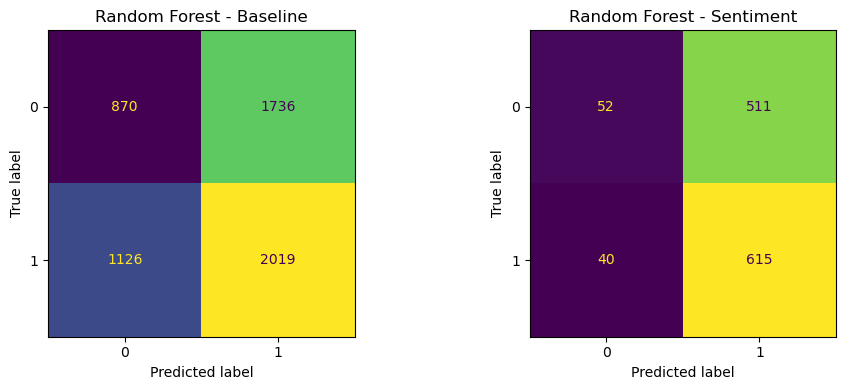

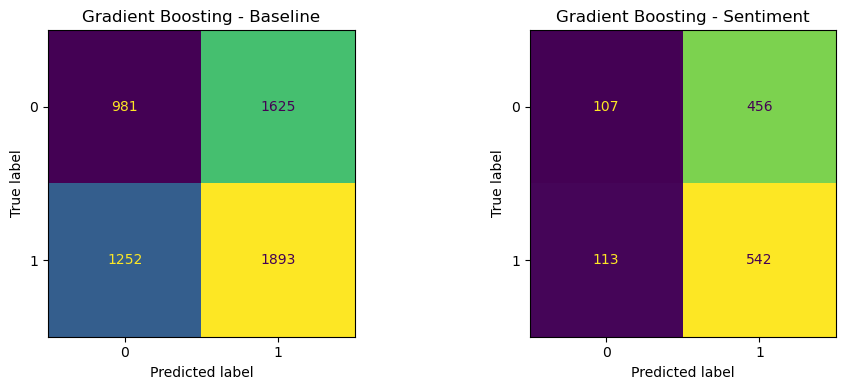

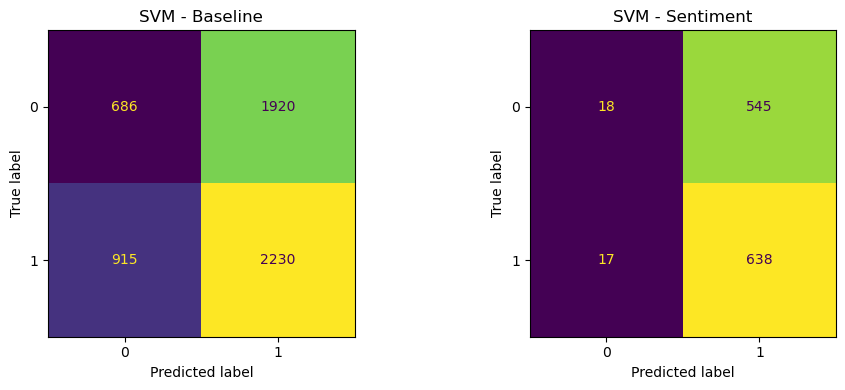

In [213]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

for name in models.keys():
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # baseline
    cm_base = confusion_matrix(
        baseline_preds[name]["y_true"],
        baseline_preds[name]["y_pred"]
    )
    ConfusionMatrixDisplay(cm_base).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f"{name} - Baseline")
    
    # sentiment
    cm_sent = confusion_matrix(
        sentiment_preds[name]["y_true"],
        sentiment_preds[name]["y_pred"]
    )
    ConfusionMatrixDisplay(cm_sent).plot(ax=axes[1], colorbar=False)
    axes[1].set_title(f"{name} - Sentiment")
    
    plt.tight_layout()
    plt.show()

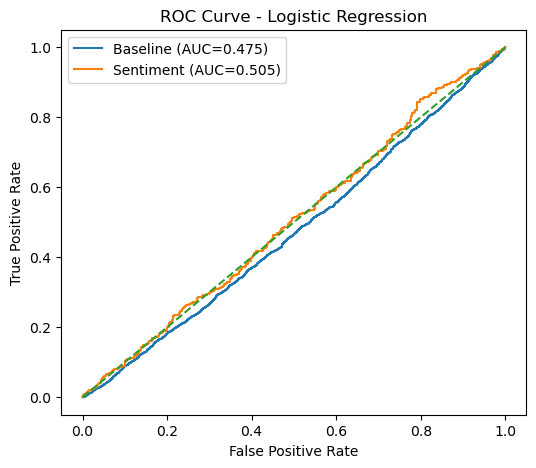

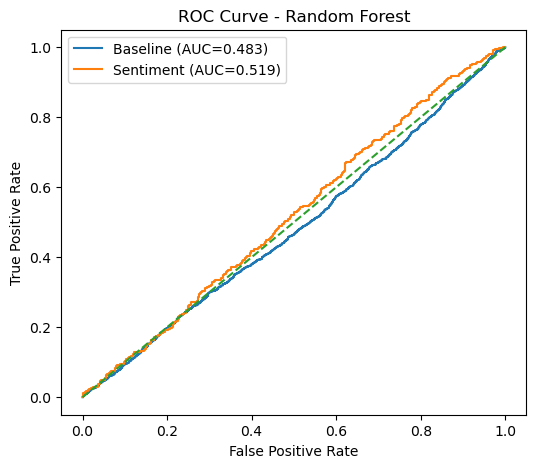

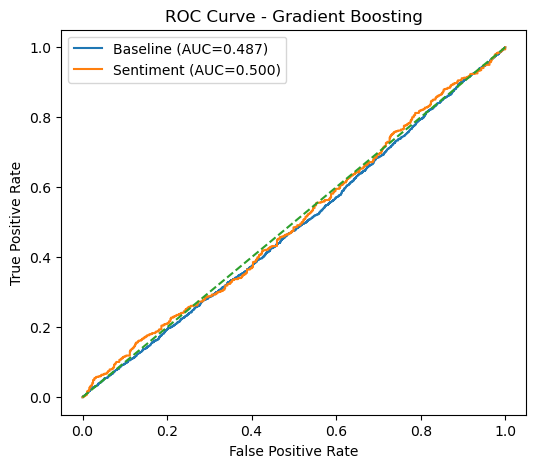

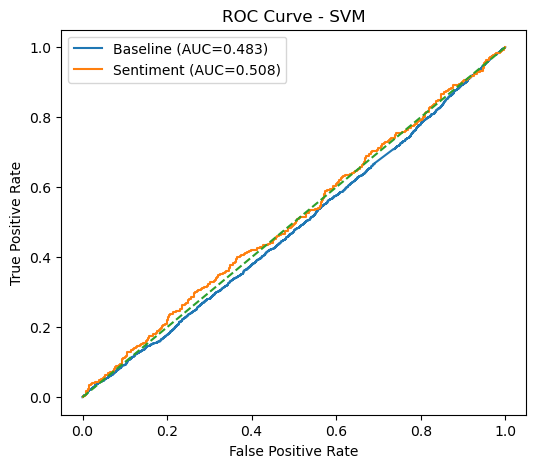

In [215]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

for name in models.keys():
    plt.figure(figsize=(6, 5))
    
    # baseline ROC
    fpr_base, tpr_base, _ = roc_curve(
        baseline_preds[name]["y_true"],
        baseline_preds[name]["y_prob"]
    )
    auc_base = auc(fpr_base, tpr_base)
    
    # sentiment ROC
    fpr_sent, tpr_sent, _ = roc_curve(
        sentiment_preds[name]["y_true"],
        sentiment_preds[name]["y_prob"]
    )
    auc_sent = auc(fpr_sent, tpr_sent)
    
    plt.plot(fpr_base, tpr_base, label=f"Baseline (AUC={auc_base:.3f})")
    plt.plot(fpr_sent, tpr_sent, label=f"Sentiment (AUC={auc_sent:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--")
    
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

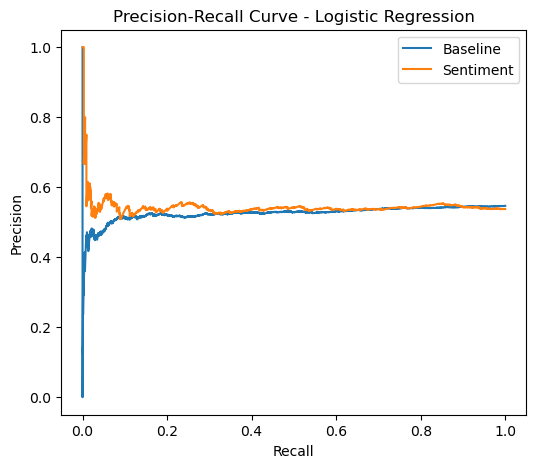

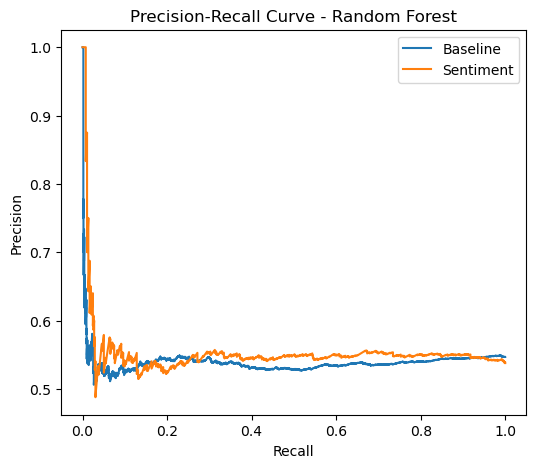

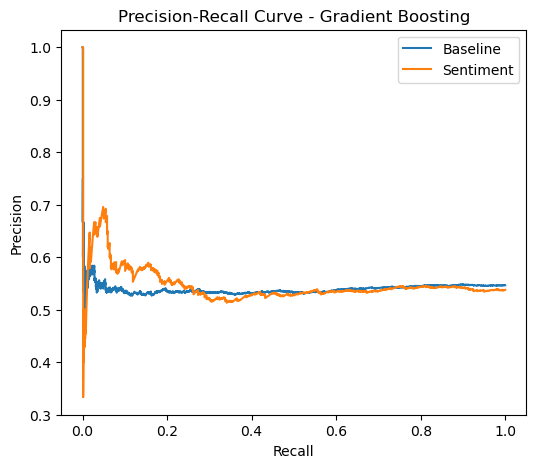

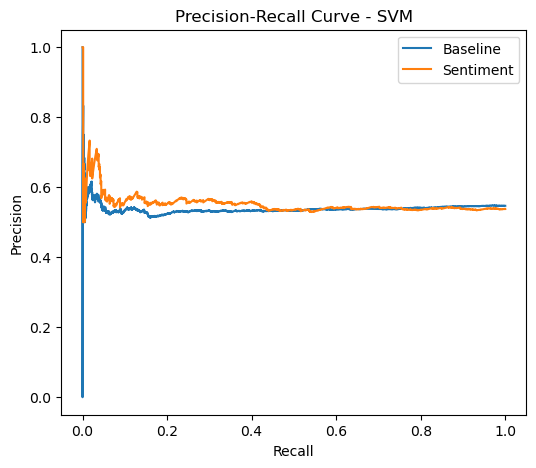

In [217]:
from sklearn.metrics import precision_recall_curve

for name in models.keys():
    plt.figure(figsize=(6, 5))
    
    # baseline
    prec_base, rec_base, _ = precision_recall_curve(
        baseline_preds[name]["y_true"],
        baseline_preds[name]["y_prob"]
    )
    
    # sentiment
    prec_sent, rec_sent, _ = precision_recall_curve(
        sentiment_preds[name]["y_true"],
        sentiment_preds[name]["y_prob"]
    )
    
    plt.plot(rec_base, prec_base, label="Baseline")
    plt.plot(rec_sent, prec_sent, label="Sentiment")
    
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Precision-Recall Curve - {name}")
    plt.legend()
    plt.show()

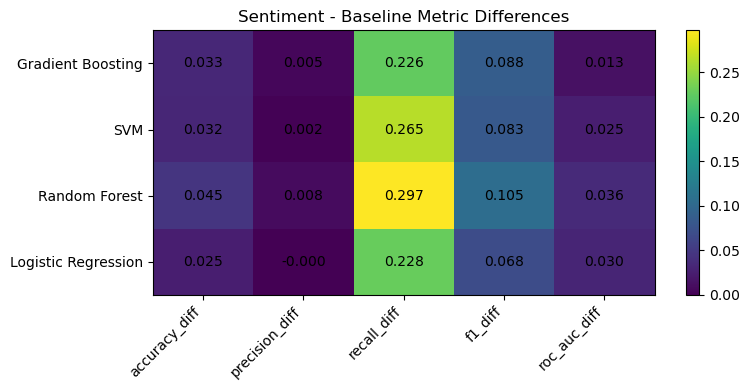

In [219]:
import matplotlib.pyplot as plt
import numpy as np

comparison_df = results_df.merge(
    results_sent_df,
    on="model",
    suffixes=("_base", "_sent")
)

metric_diff_df = pd.DataFrame({
    "model": comparison_df["model"],
    "accuracy_diff": comparison_df["accuracy_sent"] - comparison_df["accuracy_base"],
    "precision_diff": comparison_df["precision_sent"] - comparison_df["precision_base"],
    "recall_diff": comparison_df["recall_sent"] - comparison_df["recall_base"],
    "f1_diff": comparison_df["f1_sent"] - comparison_df["f1_base"],
    "roc_auc_diff": comparison_df["roc_auc_sent"] - comparison_df["roc_auc_base"]
}).set_index("model")

plt.figure(figsize=(8, 4))
plt.imshow(metric_diff_df.values, aspect="auto")
plt.xticks(range(metric_diff_df.shape[1]), metric_diff_df.columns, rotation=45, ha="right")
plt.yticks(range(metric_diff_df.shape[0]), metric_diff_df.index)

for i in range(metric_diff_df.shape[0]):
    for j in range(metric_diff_df.shape[1]):
        plt.text(j, i, f"{metric_diff_df.values[i, j]:.3f}", ha="center", va="center")

plt.title("Sentiment - Baseline Metric Differences")
plt.colorbar()
plt.tight_layout()
plt.show()

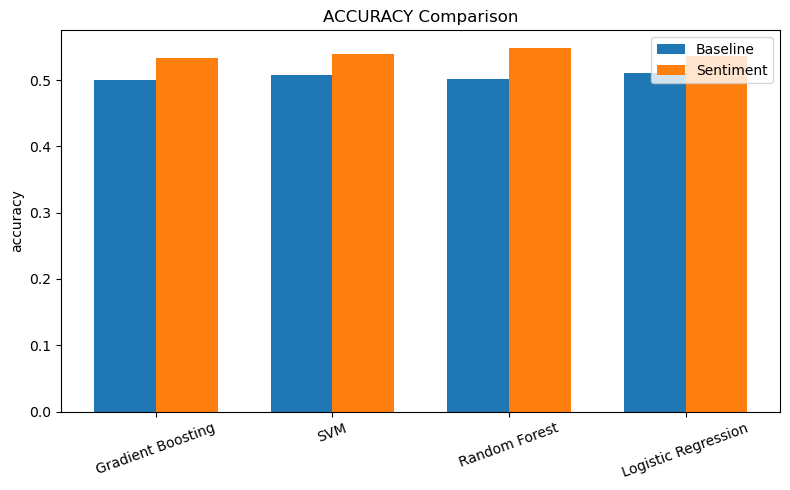

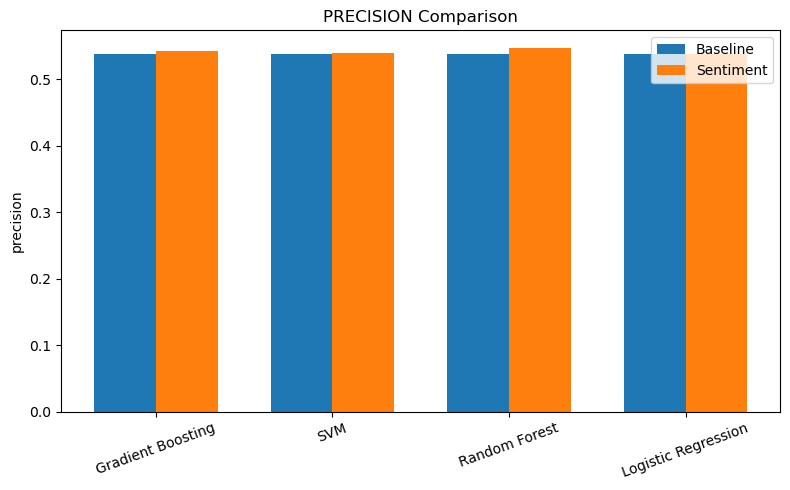

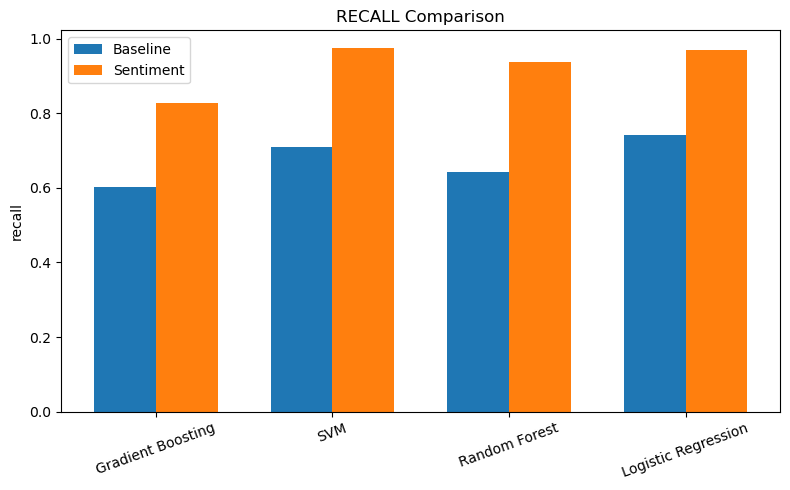

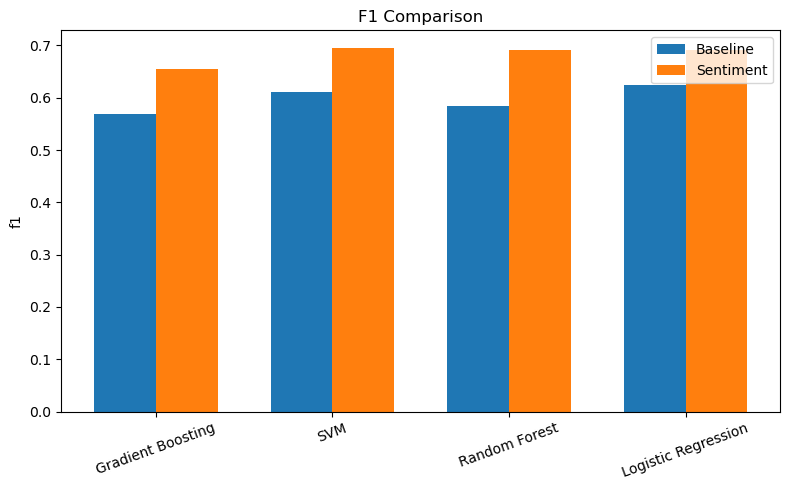

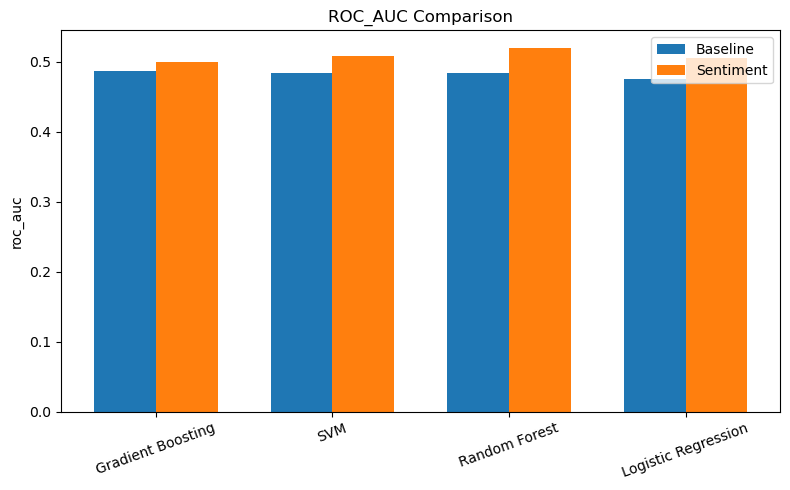

In [221]:
metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

for metric in metrics:
    plot_df = comparison_df[["model", f"{metric}_base", f"{metric}_sent"]].copy()
    x = np.arange(len(plot_df))
    width = 0.35
    
    plt.figure(figsize=(8, 5))
    plt.bar(x - width/2, plot_df[f"{metric}_base"], width, label="Baseline")
    plt.bar(x + width/2, plot_df[f"{metric}_sent"], width, label="Sentiment")
    
    plt.xticks(x, plot_df["model"], rotation=20)
    plt.ylabel(metric)
    plt.title(f"{metric.upper()} Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()